In [1]:
!pip -q install librosa soundfile
!pip -q install datasets
!pip install librosa resampy soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.0 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from IPython.display import Audio, display
import sklearn
import os
import soundfile as sf
import json
import glob, random, shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import transformers.pytorch_utils as pu
from datasets import load_dataset
import zipfile
from torch.utils.data import DataLoader
from tqdm import tqdm
import zipfile
import os
from sklearn.metrics import accuracy_score

In [4]:
zip_file_path = '/content/real_libri_speech.zip'
extraction_path = '/content/libri_speech_extracted'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

'/content/real_libri_speech.zip' unzipped to '/content/libri_speech_extracted'


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
audio_folder_real = "/content/libri_speech_extracted/real"
audio_folder_synthetic = "/content/libri_speech_extracted/fake"
list_spectrograms_real = []
list_spectrograms_synthetic = []

def extract_glottal_residual(audio_path, sample_rate=16000, lpc_order=18, frame_ms=25, hop_ms=10):
    """
    Extracts the glottal residual e(t) from an audio file using frame-based LPC inverse filtering
    and converts it into a 2D Mel-Spectrogram.

    Parameters:
    - audio_path: str, path to the wav/mp3 file
    - sample_rate: int, sampling frequency (16 kHz recommended for speech)
    - lpc_order: int, number of LPC prediction coefficients (p = sr/1000 + 2 is standard)
    - frame_ms: float, frame duration in milliseconds (25ms captures vocal tract stability)
    - hop_ms: float, frame step size in milliseconds (10ms overlap)

    Returns:
    - S_residual_db: 2D numpy array, the Mel-Spectrogram (in dB) of the extracted glottal residual.
    """
    # 1. Load audio and normalize sampling rate
    y, sr = librosa.load(audio_path, sr=sample_rate)

    # 2. Pre-emphasis filter to boost high frequencies before LPC calculation
    y_pre = librosa.effects.preemphasis(y)

    # Convert milliseconds to sample counts
    frame_length = int((frame_ms / 1000.0) * sr)
    hop_length = int((hop_ms / 1000.0) * sr)

    # 3. Frame the audio signal into sliding windows
    frames = librosa.util.frame(y_pre, frame_length=frame_length, hop_length=hop_length, axis=0)
    num_frames = frames.shape[0]

    # Pre-allocate residual array
    residual_frames = []
    window = np.hamming(frame_length)

    # 4. Frame-by-frame LPC inverse filtering
    for i in range(num_frames):
        frame = frames[i]

        # Skip silent/very low energy frames to prevent division instabilities
        if np.max(np.abs(frame)) < 1e-4:
            residual_frames.append(np.zeros(hop_length))
            continue

        # Apply Hamming window to compute prediction coefficients A(z)
        windowed_frame = frame * window
        try:
            a_coeffs = librosa.lpc(windowed_frame, order=lpc_order)
            if not np.all(np.isfinite(a_coeffs)): # Check for NaNs or Infs
                a_coeffs = np.zeros(lpc_order + 1)
                a_coeffs[0] = 1.0 # default to no filtering if LPC fails
        except Exception: # Catch any other potential errors from librosa.lpc
            a_coeffs = np.zeros(lpc_order + 1)
            a_coeffs[0] = 1.0

        # Inverse filter the unwindowed frame: E(z) = A(z) * Y(z)
        e_frame = lfilter(a_coeffs, [1.0], frame)

        # Take the hop-sized center slice to seamlessly stitch the residual array
        residual_frames.append(e_frame[:hop_length])

    # Concatenate all frame hops back into a continuous time signal
    residual = np.concatenate(residual_frames)

    # Convert residual into a 2D Mel-Spectrogram (Input for your 2D CNN)
    S_residual = librosa.feature.melspectrogram(y=residual, sr=sr, n_mels=128)
    S_residual_db = librosa.power_to_db(S_residual, ref=np.max)

    return S_residual_db

In [6]:
audio_real = []
audio_synthetic = []
labels_real = []
labels_synthetic = []
for filename in os.listdir(audio_folder_real):
    if filename.endswith(".wav"):
        filepath = os.path.join(audio_folder_real, filename)
        audio_real.append(librosa.load(filepath, sr=16000))
        labels_real.append(0)
        # extract_glottal_residual now loads audio internally and returns only the spectrogram
        spectrogram = extract_glottal_residual(filepath)
        list_spectrograms_real.append(spectrogram)

for filename in os.listdir(audio_folder_synthetic):
    if filename.endswith(".wav"):
        filepath = os.path.join(audio_folder_synthetic, filename)
        audio_synthetic.append(librosa.load(filepath, sr=16000))
        labels_synthetic.append(1)
        # extract_glottal_residual now loads audio internally and returns only the spectrogram
        spectrogram = extract_glottal_residual(filepath)
        list_spectrograms_synthetic.append(spectrogram)

In [7]:
# Determine the maximum number of time frames among all spectrograms
max_len_real = max(s.shape[1] for s in list_spectrograms_real)
max_len_synthetic = max(s.shape[1] for s in list_spectrograms_synthetic)
max_len = max(max_len_real, max_len_synthetic)

print(f"Maximum spectrogram length (time frames): {max_len}")

def pad_or_truncate(spectrogram, target_len):
    """
    Pads or truncates a spectrogram to the target_len.
    """
    num_mels, current_len = spectrogram.shape
    if current_len < target_len:
        # Pad with zeros
        padding = np.zeros((num_mels, target_len - current_len))
        padded_spectrogram = np.concatenate((spectrogram, padding), axis=1)
        return padded_spectrogram
    elif current_len > target_len:
        # Truncate
        truncated_spectrogram = spectrogram[:, :target_len]
        return truncated_spectrogram
    else:
        return spectrogram

# Apply padding/truncation to both real and synthetic spectrograms
processed_spectrograms_real = [pad_or_truncate(s, max_len) for s in list_spectrograms_real]
processed_spectrograms_synthetic = [pad_or_truncate(s, max_len) for s in list_spectrograms_synthetic]

# Convert the lists of processed spectrograms into a single NumPy array
random.seed(45)
total_spectrograms = np.array(np.concatenate((processed_spectrograms_real, processed_spectrograms_synthetic),axis=0))
total_labels = labels_real + labels_synthetic
# create a list of paired items
combined = list(zip(total_spectrograms, total_labels))
random.shuffle(combined)
total_spectrograms, total_labels = zip(*combined)
total_spectograms = np.expand_dims(total_spectrograms, axis=1)
total_labels = list(total_labels)

Maximum spectrogram length (time frames): 627


In [8]:
class AudioDataset(Dataset):
    def __init__(self, spectrograms, labels):
        self.spectrograms = torch.tensor(
            spectrograms,
            dtype=torch.float32
        )

        if self.spectrograms.ndim == 3:
            self.spectrograms = self.spectrograms.unsqueeze(1)

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.spectrograms[idx], self.labels[idx]

dataset = AudioDataset(
    total_spectrograms,
    total_labels
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

/tmp/ipykernel_539/2589150193.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.spectrograms = torch.tensor(


In [9]:
SAMPLE_RATE = 16000

class DeepFakeGlottalClassificationModel(nn.Module):
    def __init__(self, num_classes=2):
        super(DeepFakeGlottalClassificationModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3, padding = 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3,  padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,  padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64,2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        return x

In [10]:


# First, split into train+val and test (e.g., 80% train+val (60% training, 20% validation), 20% test)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    total_spectrograms,
    total_labels,
    test_size=0.2,
    random_state=45,
    stratify=total_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=45,
    stratify=y_train_val
)

# Create datasets and dataloaders
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:



def train_model(train_loader, val_loader, num_epochs=30, device='cuda'):
    num_classes= 2
    model = DeepFakeGlottalClassificationModel(num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    best_val_accuracy = 0.0
    best_val_loss = float('inf')

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()

        train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item()
                _, predicted = output.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}')

        # Save the best model
        if val_accuracy > best_val_accuracy or (val_accuracy == best_val_accuracy and val_loss < best_val_loss):
            best_val_accuracy = val_accuracy
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Best model saved | Val Acc: {best_val_accuracy:.4f} | Val Loss: {best_val_loss:.4f}')
    return model, history

# Train the model
model, history = train_model(train_loader, val_loader, num_epochs=30, device='cuda')
print("Training complete!")

Epoch 1/30 - Validation: 100%|██████████| 7/7 [00:00<00:00, 51.59it/s]


Epoch 1/30:
Train Loss: 0.6907 | Train Accuracy: 0.5067
Val Loss: 0.6925 | Val Accuracy: 0.5000
Best model saved | Val Acc: 0.5000 | Val Loss: 0.6925


Epoch 2/30 - Validation: 100%|██████████| 7/7 [00:00<00:00, 54.73it/s]


Epoch 2/30:
Train Loss: 0.6794 | Train Accuracy: 0.5450
Val Loss: 0.6817 | Val Accuracy: 0.5950
Best model saved | Val Acc: 0.5950 | Val Loss: 0.6817


Epoch 3/30 - Validation: 100%|██████████| 7/7 [00:00<00:00, 52.45it/s]


...

Epoch 28/30:
Train Loss: 0.3763 | Train Accuracy: 0.9333
Val Loss: 0.4345 | Val Accuracy: 0.8700


Epoch 29/30 - Validation: 100%|██████████| 7/7 [00:00<00:00, 53.68it/s]


Epoch 29/30:
Train Loss: 0.3743 | Train Accuracy: 0.9317
Val Loss: 0.3636 | Val Accuracy: 0.9550
Best model saved | Val Acc: 0.9550 | Val Loss: 0.3636


Epoch 30/30 - Validation: 100%|██████████| 7/7 [00:00<00:00, 54.44it/s]

Epoch 30/30:
Train Loss: 0.3504 | Train Accuracy: 0.9417
Val Loss: 0.3411 | Val Accuracy: 0.9850
Best model saved | Val Acc: 0.9850 | Val Loss: 0.3411
Training complete!


Test Loss: 0.3113, Test Accuracy: 0.9850
Classification Report:
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99       100
   Synthetic       1.00      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



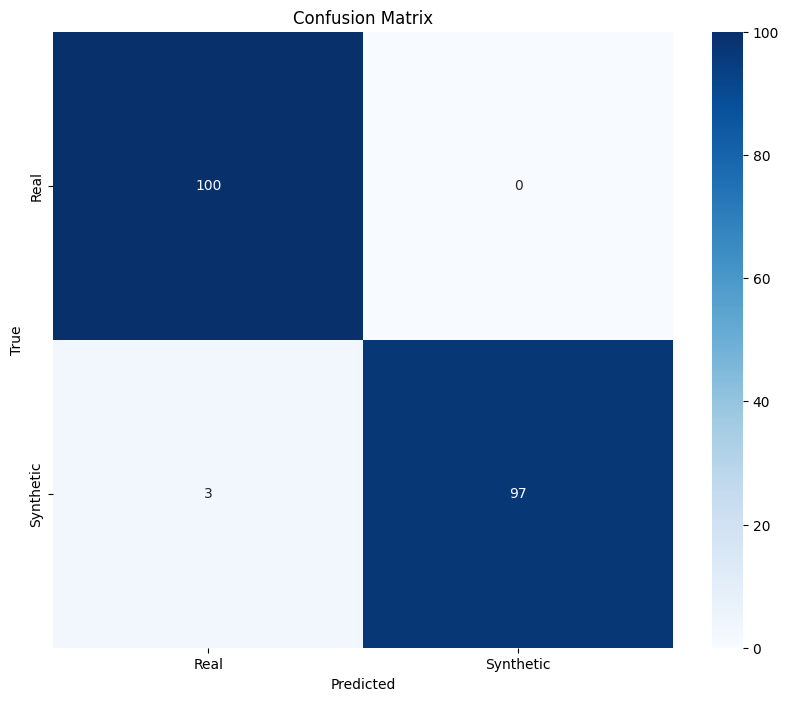

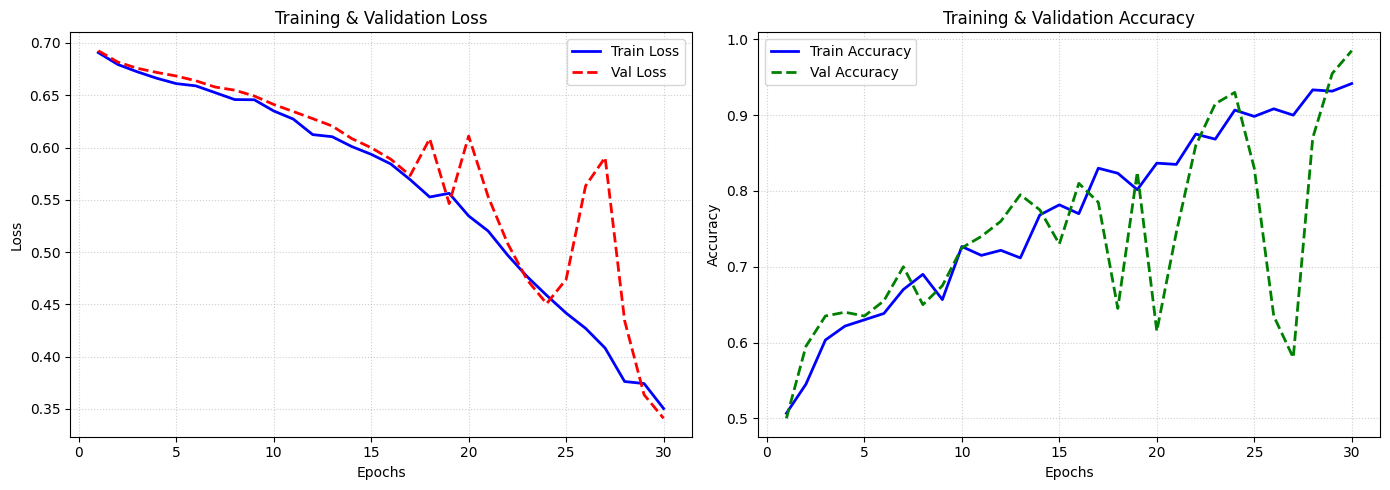

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best model
def load_best_model(model, path='best_model.pth'):
    model.load_state_dict(torch.load(path))
    return model

# Evaluate the model
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    test_loss /= len(test_loader)
    accuracy = correct / len(test_loader.dataset)

    return test_loss, accuracy, all_preds, all_labels

# Load the best model
model = load_best_model(model)
device = 'cuda'
criterion = nn.CrossEntropyLoss()
model.to(device)

# Evaluate the model
test_loss, test_accuracy, all_preds, all_labels = evaluate_model(model, test_loader, criterion, device)

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

# Generate classification report
class_names = ['Real', 'Synthetic']
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:")
print(report)

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, history['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
    plt.plot(epochs, history['val_acc'], label='Val Accuracy', color='green', linestyle='--', linewidth=2)
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

In [19]:
model = load_best_model(model, path='best_model.pth')
import os
os.rename("best_model.pth", "glottal_real_model.joblib")